# Error Correction

A code to test some error correction routines.

Let's first consider the 9-qubit Shor algorithm for detecting X and Z errors. We have the circuitfrom qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [74]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit_aer import AerSimulator
import numpy as np

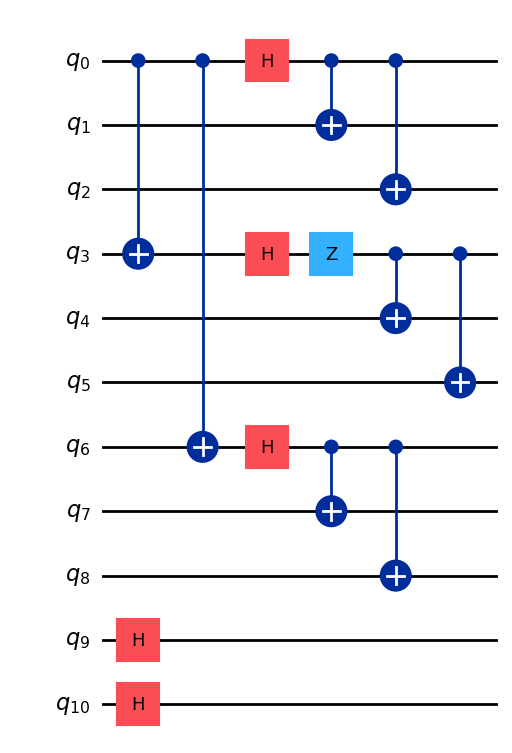

In [115]:
qc = QuantumCircuit(11)
qc.cx(0,3)
qc.cx(0,6)
qc.h(9)
qc.h(10)
for i in range(3):
    qc.h(3*i)
    if i == 1:
        qc.z(3)
    qc.cx(3*i,3*i+1)
    qc.cx(3*i,3*i+2)
display(qc.draw(output="mpl"))

In [92]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
plus = Statevector.from_label("+")
ket = zero ^ zero ^ zero ^ zero ^ zero ^ zero ^ zero ^ zero ^ zero ^ zero ^ one
display(ket.evolve(qc).draw("latex"))

<IPython.core.display.Latex object>

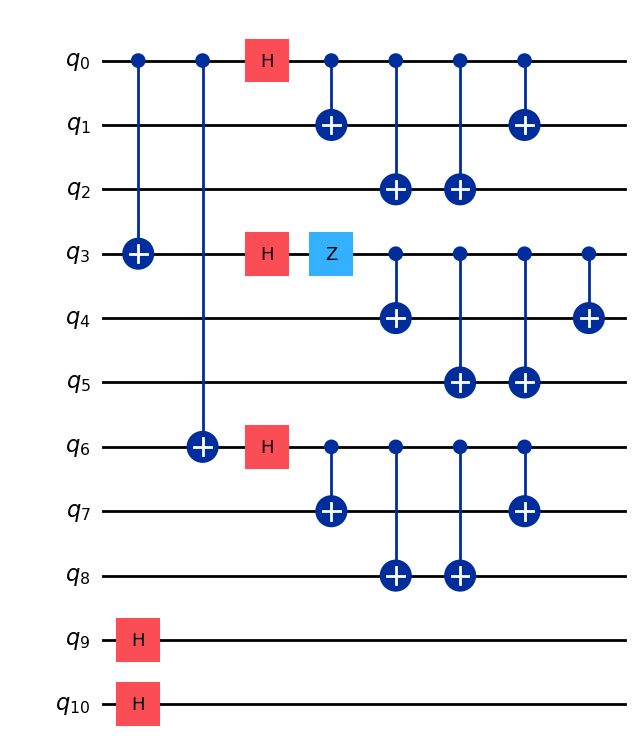

In [116]:
qc2 = QuantumCircuit(11)
qc2 = qc2.compose(qc)
for i in range(3):
    qc2.cx(3*i,3*i+2)
    qc2.cx(3*i,3*i+1)
display(qc2.draw(output="mpl"))

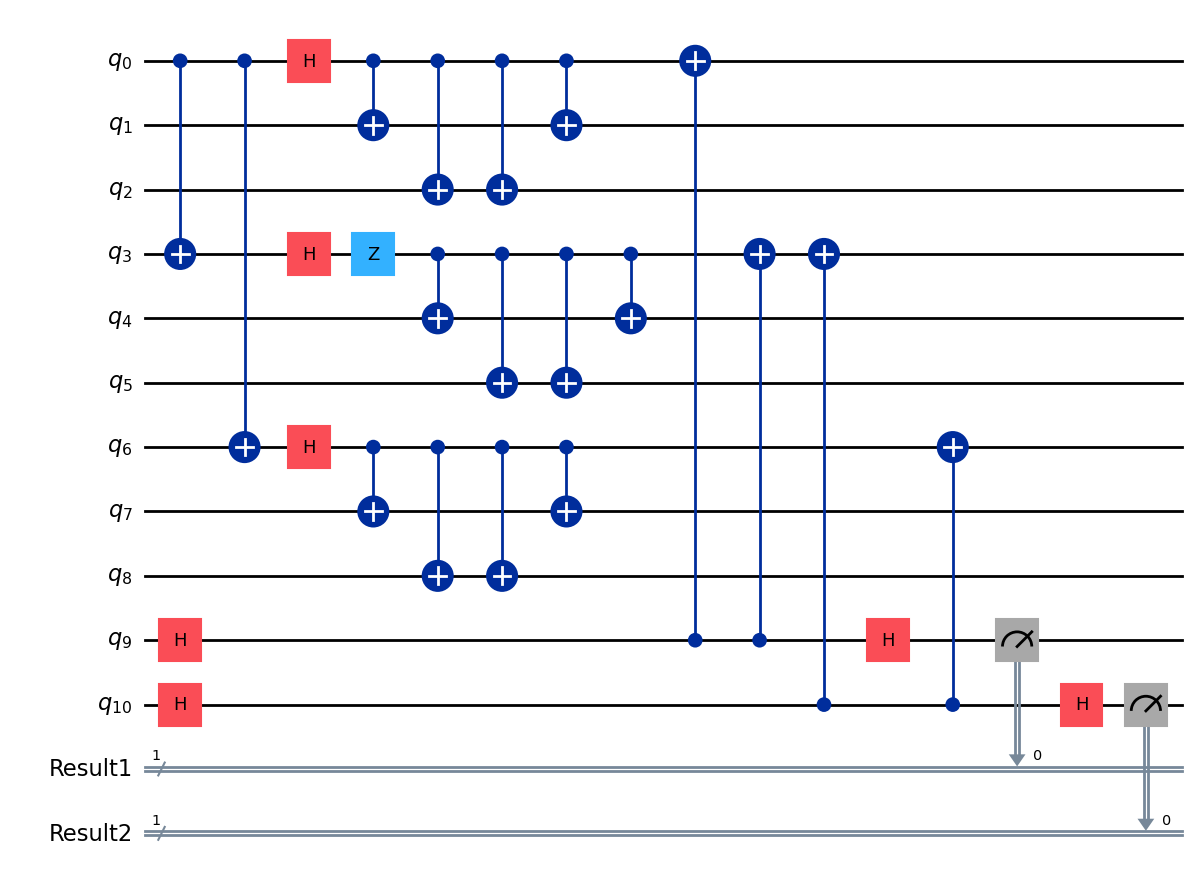

In [117]:
qc3 = QuantumCircuit(11)
qc3 = qc3.compose(qc2)
qc3.cx(9,0)
qc3.cx(9,3)
qc3.cx(10,3)
qc3.cx(10,6)
qc3.h(10)
qc3.h(9)
result1 = ClassicalRegister(1, "Result1")
result2 = ClassicalRegister(1, "Result2")
qc3.add_register(result1)
qc3.add_register(result2)
qc3.measure(9, result1)
qc3.measure(10, result2)

display(qc3.draw(output="mpl"))

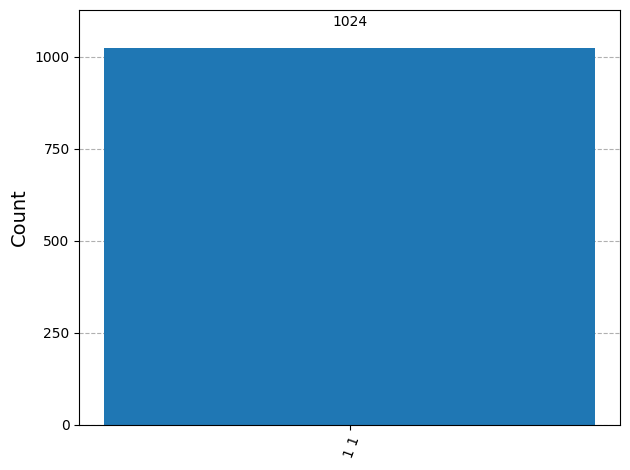

In [118]:
result = AerSimulator().run(qc3).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

Below I run a test of measuring the Z error without decoding the qubits first, which does not work.

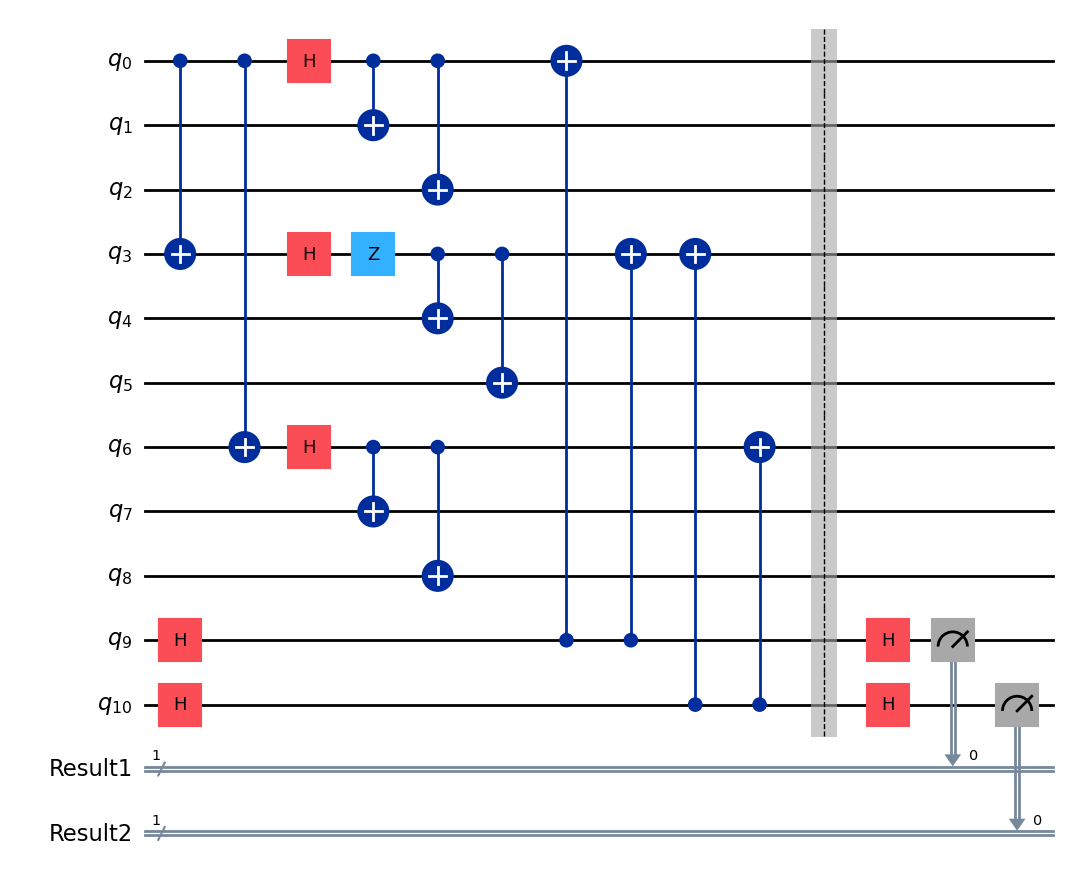

In [119]:
qc4 = QuantumCircuit(11)
qc4 = qc4.compose(qc)
qc4.cx(9,0)
qc4.cx(9,3)
qc4.cx(10,3)
qc4.cx(10,6)
qc4.barrier()
qc4.h(10)
qc4.h(9)
result1 = ClassicalRegister(1, "Result1")
result2 = ClassicalRegister(1, "Result2")
qc4.add_register(result1)
qc4.add_register(result2)
qc4.measure(9, result1)
qc4.measure(10, result2)

display(qc4.draw(output="mpl"))

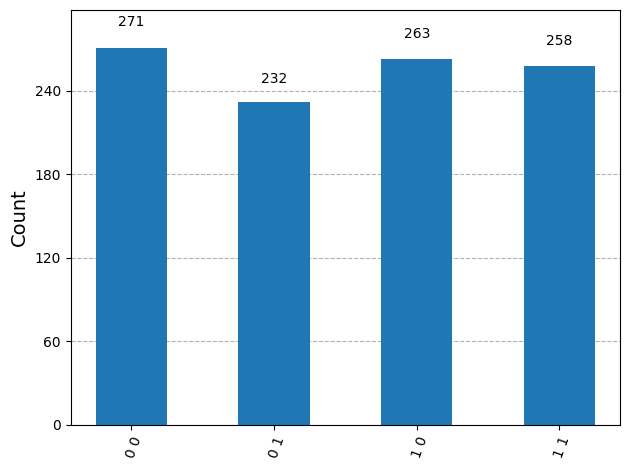

In [120]:
result = AerSimulator().run(qc4).result()
statistics = result.get_counts()
display(plot_histogram(statistics))